In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("train.csv")

df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [3]:
print("Tamanho do treino: ", df.shape)
print()
print("Colunas do treino:")
print(df.columns)

Tamanho do treino:  (891, 12)

Colunas do treino:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


## Tratamento dos Dados

In [4]:
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [ ]:
meanAge = df["Age"].mean()
df["Age"] = df["Age"].fillna(meanAge)

print(df["Cabin"].value_counts()) # muitos valores diferentes
df = df.drop("Cabin", axis=1)

moda = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(moda)

print()
print(df.isnull().sum())
print("Dados nulos tratados!")

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Análise dos Dados

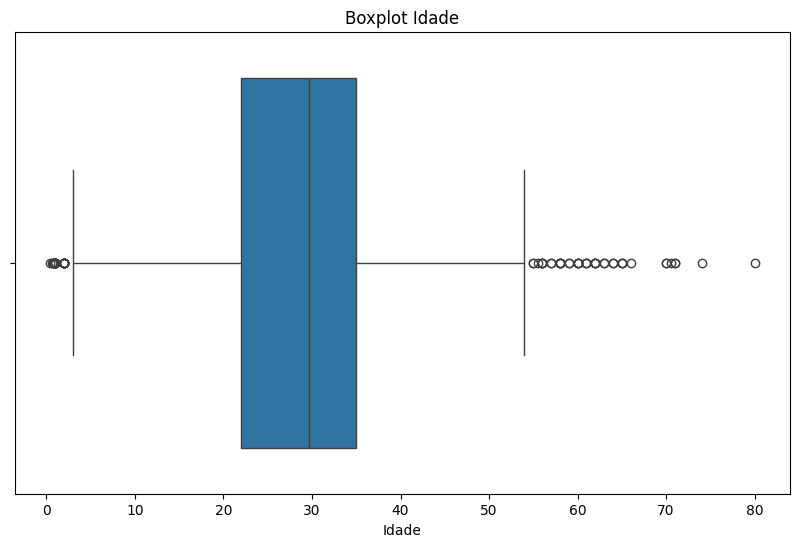

In [7]:
# boxplot da idade
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Age"])
plt.title("Boxplot Idade")
plt.xlabel("Idade")
plt.show()

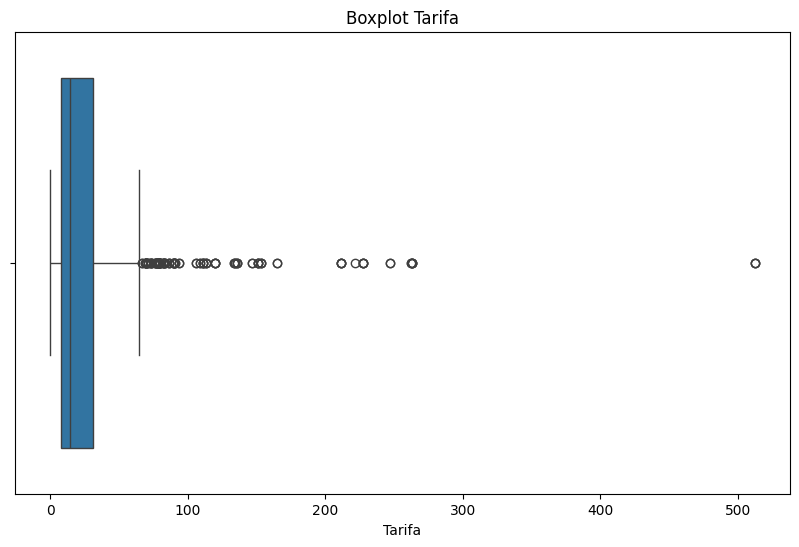

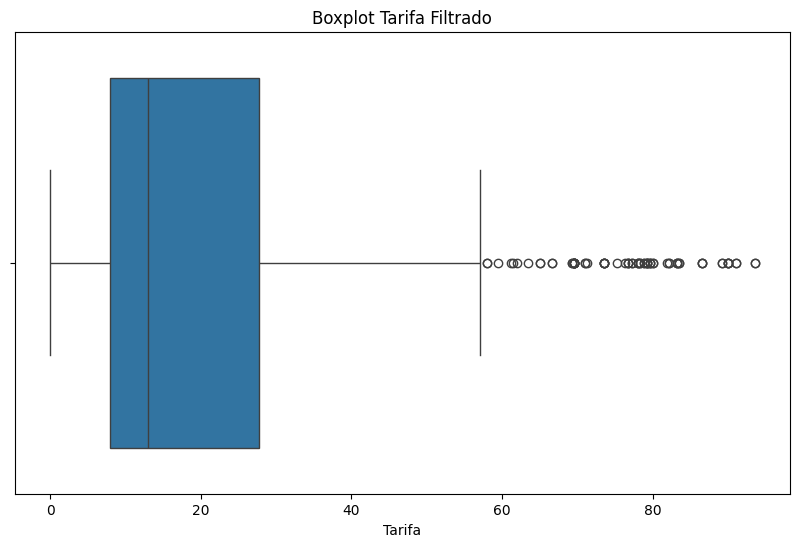

In [8]:
# boxplot da tarifa
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Fare"])
plt.title("Boxplot Tarifa")
plt.xlabel("Tarifa")
plt.show() # outliers distorcendo o boxplot

filtered = df[df["Fare"] <= 100]

plt.figure(figsize=(10,6))
sns.boxplot(x=filtered["Fare"])
plt.title("Boxplot Tarifa Filtrado")
plt.xlabel("Tarifa")
plt.show()

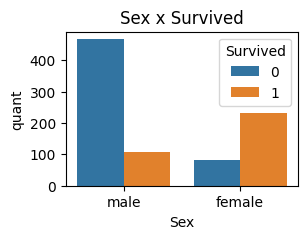

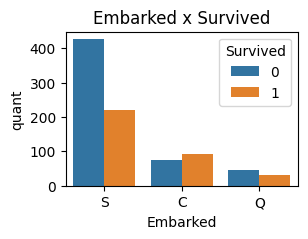

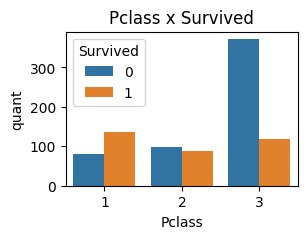

In [9]:
# gráfico de barras com colunas categoricas
for feature in ["Sex", "Embarked", "Pclass"]:
    plt.figure(figsize=(3,2))
    sns.countplot(x=feature, hue="Survived", data=df)
    plt.title(f"{feature} x Survived")
    plt.ylabel("quant")
    plt.show()

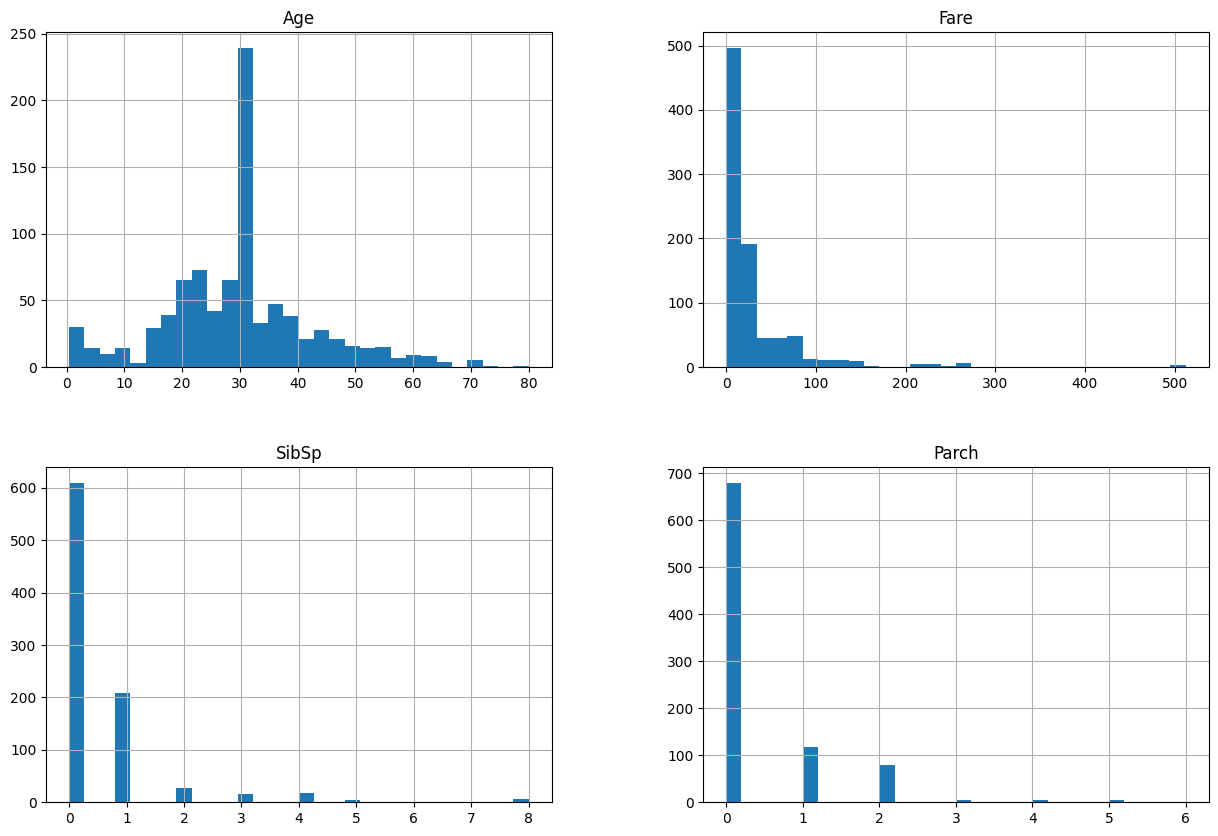

In [10]:
# histogramas
features = ["Age", "Fare", "SibSp", "Parch"]

df[features].hist(bins=30, figsize=(15,10))
plt.show()

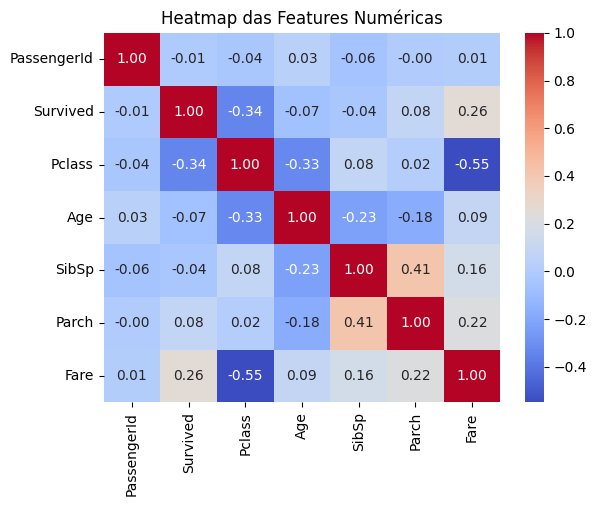

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.069809
Pclass        -0.338481
Name: Survived, dtype: float64


In [11]:
# heatmap das features
cols_numericas = df.select_dtypes(["int64", "float64"])

correlacao_df = cols_numericas.corr()
sns.heatmap(correlacao_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap das Features Numéricas")
plt.show()

print(correlacao_df["Survived"].sort_values(ascending=False))

## Treinamento do Modelo

In [12]:
# eliminação de colunas irrelevantes para o modelo
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# padronização das variáveis
df = pd.get_dummies(df, columns=["Embarked"])

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.000000,1,0,7.2500,False,False,True
1,1,1,1,38.000000,1,0,71.2833,True,False,False
2,1,3,1,26.000000,0,0,7.9250,False,False,True
3,1,1,1,35.000000,1,0,53.1000,False,False,True
4,0,3,0,35.000000,0,0,8.0500,False,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,13.0000,False,False,True
887,1,1,1,19.000000,0,0,30.0000,False,False,True
888,0,3,1,29.699118,1,2,23.4500,False,False,True
889,1,1,0,26.000000,0,0,30.0000,True,False,False


In [13]:
# separacao de variaveis alvo e preditoras
y = df["Survived"]
x = df.drop("Survived", axis=1)

# divisao 80/20 entre treino/validação
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2)

modelo = RandomForestClassifier()
modelo.fit(x_treino, y_treino)

y_pred = modelo.predict(x_teste)

print("Modelo treinado!")

Modelo treinado!


In [14]:
precisao = accuracy_score(y_teste, y_pred)
matriz_confusao = confusion_matrix(y_teste, y_pred)
relatorio = classification_report(y_teste, y_pred)

print(f"Precisão: {precisao:.2f}")
print(f"Matriz de erro:\n{matriz_confusao}")
print(f"Relatório de Classificação:\n{relatorio}")

Precisão: 0.83
Matriz de erro:
[[101  19]
 [ 11  48]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       120
           1       0.72      0.81      0.76        59

    accuracy                           0.83       179
   macro avg       0.81      0.83      0.82       179
weighted avg       0.84      0.83      0.83       179

